# Exploring Song Length 
Just looking at 4 genres: Pop, Rap, Classical, Opera

These are two of the most popular genres, as well as two of the least popular

In [ ]:
# import the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spotify = pd.read_csv('/home/owitt/eds217/SpotifyFeatures.csv')
# replace the csv path with yours!!!

In [2]:
spotify = spotify.drop_duplicates(subset=['artist_name', 'track_name'])
spotify.describe()
# dropped songs that appear multiple times 
# (i.e. songs that are listed in multiple genres)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,176514.000000,176514.000000,176514.000000,1.765140e+05,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000,176514.000000
mean,36.257634,0.403876,0.541111,2.361540e+05,0.557203,0.172211,0.224628,-10.137290,0.127471,117.214397,0.451642
std,17.392089,0.366286,0.190441,1.305749e+05,0.275855,0.323038,0.211150,6.398382,0.204460,31.323689,0.267853
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,25.000000,0.045500,0.415000,1.782800e+05,0.344000,0.000000,0.097500,-12.850000,0.036800,92.007000,0.222000
50%,37.000000,0.288000,0.558000,2.194750e+05,0.592000,0.000071,0.130000,-8.189000,0.049400,115.009000,0.440000
75%,49.000000,0.791000,0.683000,2.685730e+05,0.789000,0.091400,0.277000,-5.629000,0.102000,138.825000,0.667000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [3]:
# also, we need to combine the two different spellings 
# of "children's music" first into one genre
spotify['genre'] = spotify['genre'].str.replace('Children’s', 'Childrens')
spotify['genre'] = spotify['genre'].str.replace("Children's", 'Childrens')
 
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       'Childrens Music', 'Rap', 'Indie', 'Classical', 'Pop', 'Reggae',
       'Reggaeton', 'Jazz', 'Rock', 'Ska', 'Comedy', 'Soul', 'Soundtrack',
       'World'], dtype=object)

In [4]:
spotify_filtered = spotify[spotify['genre'].isin(['Pop', 'Rap', 'Classical', 'Opera'])]
spotify_filtered['genre'].unique()

array(['Opera', 'Rap', 'Classical', 'Pop'], dtype=object)

In [5]:
# which genre has longer songs?
grouped = spotify_filtered.groupby('genre')['duration_ms'].agg(['mean', 'max', 'min', 'count'])
filtered_df = grouped.reset_index()
filtered_df

,genre,mean,max,min,count
0,Classical,312981.590256,3391040,15509,8703
1,Opera,259161.092271,2404810,30707,8280
2,Pop,218439.330705,645876,89520,2410
3,Rap,201944.816495,760973,49242,1455


In [6]:
classical = spotify_filtered[spotify_filtered['genre'] == "Classical"]
opera = spotify_filtered[spotify_filtered['genre'] == "Opera"]
pop = spotify_filtered[spotify_filtered['genre'] == "Pop"]
rap = spotify_filtered[spotify_filtered['genre'] == "Rap"]
# create one data frame for each genre containing only that genre

In [7]:
# how many rows does each of these have? 
# (i.e. how many songs does each genre have?)

print(f"there are {len(classical)} classical songs")
print(f"there are {len(opera)} opera songs")
print(f"there are {len(pop)} pop songs")
print(f"there are {len(rap)} rap songs")

there are 8703 classical songs
there are 8280 opera songs
there are 2410 pop songs
there are 1455 rap songs


In [8]:
# filter for songs above a certain threshold
# lets say a "long" song is over eight minutes
# 8 minutes is 480,000 milliseconds

# then calculate proportion of songs of a
# certain genre that are "long"


long_classical = classical[classical['duration_ms'] > 480000]
print(f"there are {len(long_classical)} long classical songs")
percent_classical = ((len(long_classical)) / (len(classical))) * 100
print(f"{round(percent_classical, 2)}% of classical songs are long")

print(" ")

long_opera = opera[opera['duration_ms'] > 480000]
print(f"there are {len(long_opera)} long opera songs")
percent_opera = ((len(long_opera)) / (len(opera))) * 100
print(f"{round(percent_opera, 2)}% of opera songs are long")

print(" ")

long_pop = pop[pop['duration_ms'] > 480000]
print(f"there are {len(long_pop)} long pop songs")
percent_pop = ((len(long_pop)) / (len(pop))) * 100
print(f"{round(percent_pop, 2)}% of pop songs are long")

print(" ")

long_rap = rap[rap['duration_ms'] > 480000]
print(f"there are {len(long_rap)} long rap songs")
percent_rap = ((len(long_rap)) / (len(rap))) * 100
print(f"{round(percent_rap, 2)}% of rap songs are long")

there are 1292 long classical songs
14.85% of classical songs are long
 
there are 633 long opera songs
7.64% of opera songs are long
 
there are 5 long pop songs
0.21% of pop songs are long
 
there are 6 long rap songs
0.41% of rap songs are long


In [9]:
# create and apply function to classify songs as
# long/normal/short

def islong(d):
    if d > 480000:
        return "long"
    elif d < 180000:
        return "short"
    else:
        return "normal"

spotify_filtered['is long?'] = spotify_filtered['duration_ms'].apply(islong)

# gives a warning message but works!

<positron-console-cell-9>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


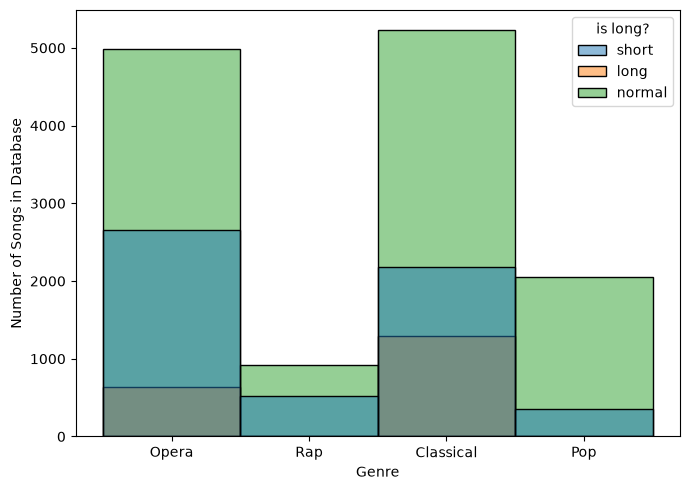

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [10]:
# Plot relative counts of
# song length cateogires for
#  our three selected genres
plt.figure(figsize=(7, 5))
sns.histplot(data=spotify_filtered, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")



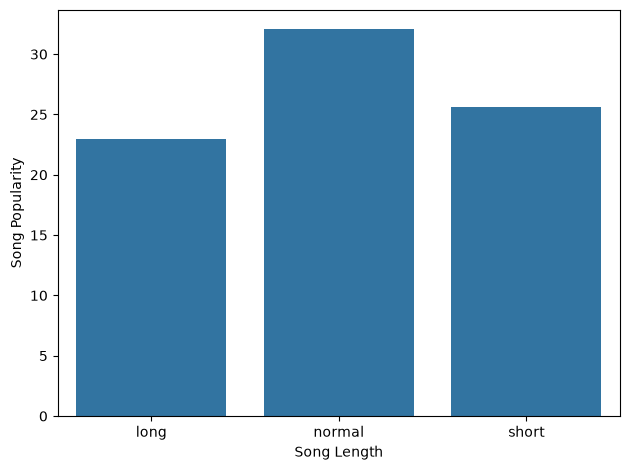

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [11]:
# compare popularity of long vs not long songs
# within these three selected genres

song_long = spotify_filtered.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")


## Same figures with the WHOLE database (all genres)

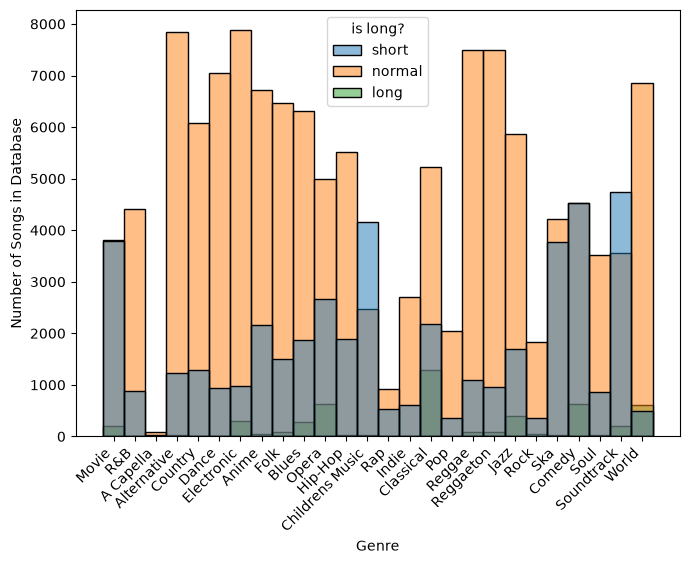

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [12]:
#go back and look at the WHOLE database:


spotify['is long?'] = spotify['duration_ms'].apply(islong)


plt.figure(figsize=(7, 5))
sns.histplot(data=spotify, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

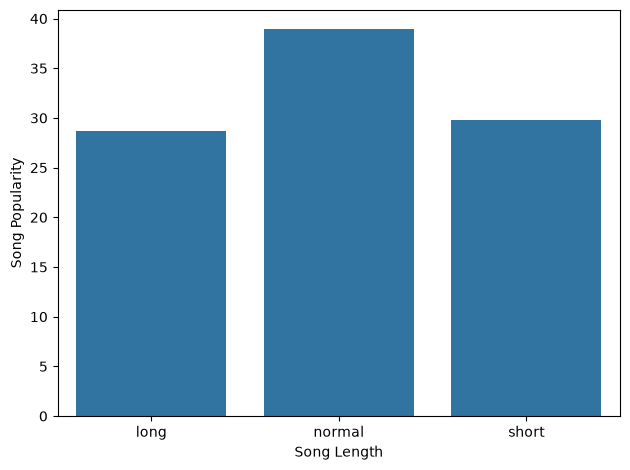

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [13]:
all_song_long = spotify.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=all_song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")
